In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [2]:
df = pd.read_csv('/kaggle/input/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(columns = ['RowNumber','CustomerId','Surname'],inplace=True)

In [6]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df['Geography'].value_counts()

France     5014
Germany    2509
Spain      2477
Name: Geography, dtype: int64

In [8]:
df['Gender'].value_counts()

Male      5457
Female    4543
Name: Gender, dtype: int64

In [9]:
df = pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [10]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [14]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [20]:
X_train_trf

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [19]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential 
from tensorflow.keras.layers import Dense

In [43]:
model = Sequential()

model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(11,activation = 'relu'))
model.add(Dense(1,activation='sigmoid'))

In [44]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_8 (Dense)              (None, 11)                132       
_________________________________________________________________
dense_9 (Dense)              (None, 11)                132       
_________________________________________________________________
dense_10 (Dense)             (None, 1)                 12        
Total params: 276
Trainable params: 276
Non-trainable params: 0
_________________________________________________________________


In [45]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics = ['accuracy'])

In [46]:
history = model.fit(X_train_trf,y_train,epochs=100, validation_split = 0.2)

Epoch 1/100
200/200 [==============================] - 1s 4ms/step - loss: 0.5379 - accuracy: 0.7858 - val_loss: 0.4673 - val_accuracy: 0.7969
Epoch 2/100
200/200 [==============================] - 0s 2ms/step - loss: 0.4513 - accuracy: 0.7958 - val_loss: 0.4439 - val_accuracy: 0.7969
Epoch 3/100
200/200 [==============================] - 0s 2ms/step - loss: 0.4336 - accuracy: 0.7958 - val_loss: 0.4366 - val_accuracy: 0.7969
Epoch 4/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4254 - accuracy: 0.8052 - val_loss: 0.4313 - val_accuracy: 0.8200
Epoch 5/100
200/200 [==============================] - 0s 2ms/step - loss: 0.4190 - accuracy: 0.8205 - val_loss: 0.4265 - val_accuracy: 0.8213
Epoch 6/100
200/200 [==============================] - 0s 2ms/step - loss: 0.4141 - accuracy: 0.8252 - val_loss: 0.4230 - val_accuracy: 0.8213
Epoch 7/100
200/200 [==============================] - 1s 3ms/step - loss: 0.4096 - accuracy: 0.8272 - val_loss: 0.4175 - val_accuracy: 0.8213

In [48]:
model.layers[2].get_weights()

[array([[ 0.97209215],
        [-0.23531199],
        [-0.29703528],
        [-1.1518605 ],
        [-1.261926  ],
        [-0.24350987],
        [ 0.9164025 ],
        [ 1.5567638 ],
        [-0.9780338 ],
        [ 0.39693758],
        [-1.0912795 ]], dtype=float32),
 array([0.12025825], dtype=float32)]

In [50]:
y_log = model.predict(X_test_trf)

In [51]:
y_pred = np.where(y_log > 0.5, 1,0)

In [52]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8595

In [55]:
history.history

{'loss': [0.5379058122634888,
  0.4513090252876282,
  0.4335781931877136,
  0.4253613352775574,
  0.4189748764038086,
  0.4140752851963043,
  0.4096237123012543,
  0.4049949645996094,
  0.39886343479156494,
  0.39124366641044617,
  0.3796513080596924,
  0.36720994114875793,
  0.3566424250602722,
  0.34948956966400146,
  0.34459388256073,
  0.34190478920936584,
  0.33949747681617737,
  0.3378474712371826,
  0.3365163803100586,
  0.3352656662464142,
  0.3345283567905426,
  0.3336377739906311,
  0.33263587951660156,
  0.3326636254787445,
  0.33128902316093445,
  0.3301699459552765,
  0.32955166697502136,
  0.32905474305152893,
  0.328454852104187,
  0.3280723989009857,
  0.32785362005233765,
  0.32697007060050964,
  0.3266149163246155,
  0.32663172483444214,
  0.3256807327270508,
  0.325364351272583,
  0.32499828934669495,
  0.3243172764778137,
  0.3241742253303528,
  0.3239416480064392,
  0.3234783411026001,
  0.32337096333503723,
  0.3233264982700348,
  0.32300040125846863,
  0.32232609

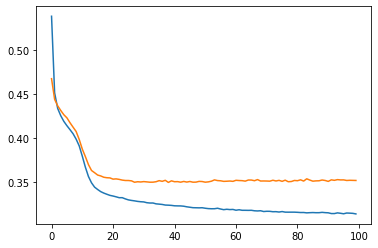

In [53]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

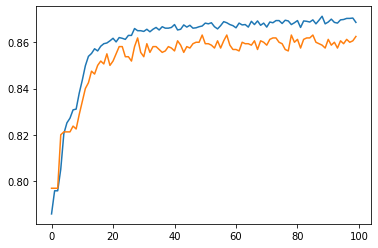

In [54]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])